# Table 3 Benchmarking — Met-3DNet-VI/VII vs All Comparators
## BIB Submission | Datasets: met3dneoantigen-v7 + tumoragdb2-0

**This notebook:**
1. Auto-discovers all mounted Kaggle datasets (no hardcoded paths)
2. Loads `test_set_for_competitors.csv` as the master test set
3. Loads existing results: DeepImmuno (`deepimmuno-cnn-result.txt.txt`), PRIME 2.0 (`prime_scores_final.csv`)
4. Generates input files for DeepHLApan, IEDB Immunogenicity servers
5. After uploading server outputs to `/kaggle/working/`, computes full Table 3

**Add these Kaggle datasets before running:**
- `neetuaashi/met3dneoantigen-v7`
- `neetuaashi/tumoragdb2-0`


## 0  Auto-Discover All Files Across Mounted Datasets

In [1]:
import os, glob

WRK = '/kaggle/working'
os.makedirs(WRK, exist_ok=True)

# ── Step 1: discover every mounted dataset ───────────────────────────────────
INPUT_ROOT = '/kaggle/input'
all_datasets = []
if os.path.isdir(INPUT_ROOT):
    all_datasets = sorted(os.listdir(INPUT_ROOT))

print('=== MOUNTED DATASETS ===')
for ds in all_datasets:
    ds_path = os.path.join(INPUT_ROOT, ds)
    try:
        files = os.listdir(ds_path)
        print(f'  {ds_path}/  ({len(files)} files)')
        for f in sorted(files)[:8]:
            print(f'    {f}')
    except: pass

# ── Step 2: build a flat index of ALL files across ALL datasets ──────────────
_file_index = {}   # filename -> full path (first match wins)
# Recursive walk — finds files in subdirectories (e.g. dataset/SubFolder/file.txt)
for ds in all_datasets:
    ds_path = os.path.join(INPUT_ROOT, ds)
    try:
        for dirpath, _, fnames in os.walk(ds_path):
            for fname in fnames:
                full = os.path.join(dirpath, fname)
                if fname not in _file_index:
                    _file_index[fname] = full
    except: pass
# Also index /kaggle/working (overrides dataset files)
for fname in os.listdir(WRK):
    full = os.path.join(WRK, fname)
    if os.path.isfile(full):
        _file_index[fname] = full

# Debug: print all IEDB-related files found
print('IEDB files in index:',
      [k for k in _file_index if 'iedb' in k.lower()])

def find_file(name):
    # 1. exact match in index
    if name in _file_index: return _file_index[name]
    # 2. case-insensitive match
    nl = name.lower()
    for k, v in _file_index.items():
        if k.lower() == nl: return v
    # 3. glob across all datasets (handles spaces in filenames)
    for ds in all_datasets:
        for p in glob.glob(os.path.join(INPUT_ROOT, ds, '**', name), recursive=True):
            if os.path.isfile(p): return p
    # 4. working directory
    p = os.path.join(WRK, name)
    if os.path.isfile(p): return p
    return None

print(f'\n{len(_file_index)} files indexed across {len(all_datasets)} datasets')


=== MOUNTED DATASETS ===
  /kaggle/input/datasets/  (1 files)
    neetuaashi
IEDB files in index: ['input_iedb_batch1_peptide_table_87d87295.csv', 'input_iedb_batch3_peptide_table_2d994478.csv', 'input_iedb_batch2.txt', 'input_iedb_batch1.txt', 'input_iedb_batch3.txt', 'input_iedb_batch2_peptide_table_6e40b7bc.csv']

104 files indexed across 1 datasets


## 1  Resolve File Paths

In [2]:
# ── Resolve all required files using the flat index ──────────────────────────
TEST_CSV          = find_file('test_set_for_competitors.csv')
DEEPIMMUNO_RESULT = find_file('deepimmuno-cnn-result.txt.txt') or find_file('deepimmuno-cnn-result.txt')
DEEPIMMUNO_GT     = find_file('deepimmuno_ground_truth.csv')
DEEPIMMUNO_INPUT  = find_file('deepimmuno_web_input.csv') or find_file('Deep immuno_test_set_for_competitors.csv')
PRIME_SCORES      = find_file('prime_scores_final.csv')
PRIME_GT          = find_file('prime_ground_truth.csv')
PRIME_GT2         = find_file('prime_ground_truth(1).csv')
SEQ2NEO_GT        = find_file('seq2neo_ground_truth.csv')
SPLIT_TEST        = find_file('split_test_upgraded.parquet')

# New server outputs -- upload to /kaggle/working/ after submission
DEEPHLAPAN_OUT = find_file('deephlapan_output.csv')
# NGT files are discovered dynamically in Cell 6 via find_ngt_batch()
IEDB_OUT_B1    = find_file('iedb_output_batch1.txt')  # legacy fallback
IEDB_OUT_B2    = find_file('iedb_output_batch2.txt')  # legacy fallback
IEDB_OUT_B3    = find_file('iedb_output_batch3.txt')  # legacy fallback

print('=== FILE RESOLUTION ===')
required = [
    ('TEST SET',             TEST_CSV),
    ('DeepImmuno result',    DEEPIMMUNO_RESULT),
    ('DeepImmuno GT',        DEEPIMMUNO_GT),
    ('PRIME 2.0 scores',     PRIME_SCORES),
    ('PRIME 2.0 GT',         PRIME_GT),
]
pending = [
    ('DeepHLApan output',    DEEPHLAPAN_OUT,   'biopharm.zju.edu.cn/deephlapan'),
    ('IEDB batch 1',         IEDB_OUT_B1,      'tools.iedb.org/immunogenicity'),
]
for label, path in required:
    ok = os.path.isfile(str(path)) if path else False
    print(f'  {"OK" if ok else "MISSING":<7}  {label:<25}: {path or "NOT FOUND"}')
for label, path, server in pending:
    ok = os.path.isfile(str(path)) if path else False
    tag = 'READY' if ok else f'pending -> {server}'
    print(f'  {"READY" if ok else "pending":<7}  {label:<25}: {path or "not uploaded yet"}')

if TEST_CSV is None:
    print('\nFATAL: test_set_for_competitors.csv not found.')
    print('Make sure the met3dneoantigen-v7 dataset is added to this notebook.')
    print('Settings -> Add data -> search: neetuaashi/met3dneoantigen-v7')


=== FILE RESOLUTION ===
  OK       TEST SET                 : /kaggle/input/datasets/neetuaashi/met3dneoantigen-v7/test_set_for_competitors.csv
  OK       DeepImmuno result        : /kaggle/input/datasets/neetuaashi/met3dneoantigen-v7/deepimmuno-cnn-result.txt.txt
  OK       DeepImmuno GT            : /kaggle/input/datasets/neetuaashi/met3dneoantigen-v7/deepimmuno_ground_truth.csv
  OK       PRIME 2.0 scores         : /kaggle/input/datasets/neetuaashi/met3dneoantigen-v7/prime_scores_final.csv
  OK       PRIME 2.0 GT             : /kaggle/input/datasets/neetuaashi/met3dneoantigen-v7/prime_ground_truth.csv
  READY    DeepHLApan output        : /kaggle/input/datasets/neetuaashi/different-neoantigen-dataset/deephlapan_output.csv
  pending  IEDB batch 1             : not uploaded yet


## 2  Environment Setup

In [3]:
import subprocess, sys
for pkg in ['numpy','pandas','scipy','scikit-learn','matplotlib','pyarrow']:
    try: __import__(pkg.replace('-','_'))
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import numpy as np
import pandas as pd
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              f1_score, accuracy_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight',
})
print('Libraries ready')


Libraries ready


## 3  Load Test Set

In [4]:
if TEST_CSV is None:
    raise FileNotFoundError(
        'test_set_for_competitors.csv not found.\n'
        'Add dataset: Settings -> Add data -> neetuaashi/met3dneoantigen-v7'
    )

test_df = pd.read_csv(TEST_CSV)
test_df.columns = [c.lower().strip() for c in test_df.columns]
print(f'Test set: {test_df.shape}')
print(f'Columns:  {list(test_df.columns)}')

# ── Detect label column: could be 'label', 'immunogenicity', 'response', etc. ─
LABEL_COL = next(
    (c for c in ['label','immunogenicity','immunogenic','response','y','target']
     if c in test_df.columns), None)
if LABEL_COL is None:
    raise ValueError(
        f'No label column found. Available: {list(test_df.columns)}\n'
        'Expected one of: label, immunogenicity, immunogenic, response'
    )
if LABEL_COL != 'label':
    test_df = test_df.rename(columns={LABEL_COL: 'label'})
    print(f'Renamed column "{LABEL_COL}" -> "label"')

# ── Detect peptide column ──────────────────────────────────────────────────────
PEP_COL = next(
    (c for c in ['peptide','neoantigen','sequence','mut_peptide','peptide_seq']
     if c in test_df.columns), None)
if PEP_COL and PEP_COL != 'peptide':
    test_df = test_df.rename(columns={PEP_COL: 'peptide'})
    print(f'Renamed column "{PEP_COL}" -> "peptide"')

# ── Detect HLA column ─────────────────────────────────────────────────────────
HLA_COL = next(
    (c for c in ['hla','hla_allele','allele','mhc','hla_type']
     if c in test_df.columns), None)
if HLA_COL and HLA_COL != 'hla':
    test_df = test_df.rename(columns={HLA_COL: 'hla'})
    print(f'Renamed column "{HLA_COL}" -> "hla"')

y_true      = test_df['label'].values.astype(int)
peptides    = test_df['peptide'].values
hla_alleles = test_df['hla'].values if 'hla' in test_df.columns else None

print(f'\nLabel distribution: {pd.Series(y_true).value_counts().to_dict()}')
print(f'Positive rate: {y_true.mean():.1%}  n_pos={y_true.sum()}  n={len(y_true)}')
if hla_alleles is not None:
    print(f'Top 8 HLA alleles:')
    print(pd.Series(hla_alleles).value_counts().head(8).to_string())


Test set: (1200, 3)
Columns:  ['peptide', 'hla_allele', 'immunogenicity']
Renamed column "immunogenicity" -> "label"
Renamed column "hla_allele" -> "hla"

Label distribution: {0: 900, 1: 300}
Positive rate: 25.0%  n_pos=300  n=1200
Top 8 HLA alleles:
HLA-A*02:01    643
HLA-A*24:02     92
HLA-A*01:01     87
HLA-B*07:02     78
HLA-A*11:01     30
HLA-B*15:01     27
HLA-B*27:05     27
HLA-B*35:01     21


## 4  Load Existing Competitor Results (DeepImmuno + PRIME 2.0)

In [5]:
def pick_col(df, candidates):
    """Find best column from a priority list; fall back to first numeric col."""
    cols_lower = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns: return cand
        if cand.lower() in cols_lower: return cols_lower[cand.lower()]
    # fallback: first float/numeric column that isn't an index
    skip = {'index','row','id','pos','position','rank_index'}
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]) and c.lower() not in skip:
            return c
    return None

def youden_metrics(y, sc):
    """AUROC + DeLong CI + F1/Acc at Youden threshold."""
    from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
    from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
    auc = roc_auc_score(y, sc)
    if auc < 0.5: sc = 1-sc; auc = 1-auc
    ap = average_precision_score(y, sc)
    fpr_v,tpr_v,thr_v = roc_curve(y, sc)
    j = np.argmax(tpr_v-fpr_v); thr = thr_v[j]
    yp = (sc>=thr).astype(int)
    np_,nn_ = y.sum(),(1-y).sum()
    q1=auc/(2-auc); q2=2*auc**2/(1+auc)
    var=max(0,(auc*(1-auc)+(np_-1)*(q1-auc**2)+(nn_-1)*(q2-auc**2))/(np_*nn_))
    return {'auroc':auc,'ci_lo':max(0,auc-1.96*var**.5),'ci_hi':min(1,auc+1.96*var**.5),
            'ap':ap,'f1':f1_score(y,yp,zero_division=0),'acc':accuracy_score(y,yp),
            'prec':precision_score(y,yp,zero_division=0),'rec':recall_score(y,yp,zero_division=0),
            'n':len(y),'scores':sc,'labels':y,'fpr':fpr_v,'tpr':tpr_v}

existing = {}
FALLBACK_DI    = {'auroc':0.589,'ci_lo':None,'ci_hi':None,'f1':0.398,'acc':0.475,'n':1058,'note':'pre-computed'}
FALLBACK_PRIME = {'auroc':0.845,'ci_lo':None,'ci_hi':None,'f1':0.564,'acc':0.819,'n':1180,'note':'IEDB overlap dagger (pre-computed)'}

# ---- DeepImmuno --------------------------------------------------------------
try:
    gt_di = pd.read_csv(DEEPIMMUNO_GT)
    gt_di.columns = [c.lower().strip() for c in gt_di.columns]
    try:    res_di = pd.read_csv(DEEPIMMUNO_RESULT, sep='\t')
    except: res_di = pd.read_csv(DEEPIMMUNO_RESULT)
    res_di.columns = [c.lower().strip() for c in res_di.columns]
    print(f'DeepImmuno result cols: {list(res_di.columns)}')
    print(f'DeepImmuno GT cols:     {list(gt_di.columns)}')

    sc_col = pick_col(res_di,['immunogenicity','score','cnn_score','prediction','prob','output'])
    y_col  = pick_col(gt_di, ['immunogenicity','label','immunogenic','ground_truth','y_true','response'])
    print(f'  Score col: {sc_col!r}  |  Label col: {y_col!r}')

    if sc_col and y_col:
        # Rename to _score and _label BEFORE merge to avoid same-column ambiguity
        r2 = res_di.rename(columns={sc_col: '_score'})
        g2 = gt_di.rename(columns={y_col:  '_label'})
        if 'peptide' in r2.columns and 'peptide' in g2.columns:
            merged = pd.merge(g2[['peptide','_label']], r2[['peptide','_score']],
                              on='peptide', how='inner')
            sc = pd.to_numeric(merged['_score'],errors='coerce').fillna(0).values
            y  = pd.to_numeric(merged['_label'],errors='coerce').fillna(0).values.astype(int)
            print(f'  Merged on peptide: {len(merged)} rows')
        else:
            n  = min(len(res_di),len(gt_di))
            sc = pd.to_numeric(res_di[sc_col],errors='coerce').fillna(0).values[:n]
            y  = pd.to_numeric(gt_di[y_col], errors='coerce').fillna(0).values.astype(int)[:n]
            print(f'  Aligned by position: {n} rows')

        m = youden_metrics(y,sc); m['note']='9/10-mer only; 62 HLA alleles'
        existing['DeepImmuno (Li et al., 2021)'] = m
        print(f'  AUROC={m["auroc"]:.4f}  F1={m["f1"]:.3f}  Acc={m["acc"]*100:.1f}%  n={len(y)}')
    else:
        print(f'  Column not identified -- using pre-computed values')
        existing['DeepImmuno (Li et al., 2021)'] = FALLBACK_DI
except Exception as e:
    print(f'DeepImmuno error: {e}')
    existing['DeepImmuno (Li et al., 2021)'] = FALLBACK_DI

# ---- PRIME 2.0 ---------------------------------------------------------------
try:
    sc_p = pd.read_csv(PRIME_SCORES)
    gt_p = pd.read_csv(PRIME_GT)
    sc_p.columns = [c.lower().strip() for c in sc_p.columns]
    gt_p.columns = [c.lower().strip() for c in gt_p.columns]
    print(f'\nPRIME scores cols: {list(sc_p.columns)}')
    print(f'PRIME GT cols:     {list(gt_p.columns)}')

    # PRIME score: higher = more immunogenic (not percentile rank)
    sc_col = pick_col(sc_p,['score','prime_score','%rank','percentile_rank',
                             'prediction','immunogenicity','prob'])
    y_col  = pick_col(gt_p,['immunogenicity','label','immunogenic','ground_truth','y_true','response'])
    print(f'  Score col: {sc_col!r}  |  Label col: {y_col!r}')

    if sc_col and y_col:
        if 'peptide' in sc_p.columns and 'peptide' in gt_p.columns:
            merged = pd.merge(gt_p[['peptide',y_col]],
                              sc_p[['peptide',sc_col]], on='peptide', how='inner')
            sc = pd.to_numeric(merged[sc_col],errors='coerce').fillna(0).values
            y  = pd.to_numeric(merged[y_col], errors='coerce').fillna(0).values.astype(int)
            print(f'  Merged on peptide: {len(merged)} rows')
        else:
            n  = min(len(sc_p),len(gt_p))
            sc = pd.to_numeric(sc_p[sc_col],errors='coerce').fillna(0).values[:n]
            y  = pd.to_numeric(gt_p[y_col], errors='coerce').fillna(0).values.astype(int)[:n]
            print(f'  Aligned by position: {n} rows')

        # If score looks like %Rank (0-100, lower=better), invert it
        if sc.mean() > 1.0:
            print(f'  Score mean={sc.mean():.1f} > 1 -- treating as %Rank, converting to 1-%rank/100')
            sc = 1.0 - sc/100.0

        m = youden_metrics(y,sc); m['note']='IEDB overlap dagger'
        existing['PRIME 2.0 (Schmidt et al., 2021)'] = m
        print(f'  AUROC={m["auroc"]:.4f}  F1={m["f1"]:.3f}  Acc={m["acc"]*100:.1f}%  n={len(y)}')
    else:
        print(f'  Column not identified -- using pre-computed values')
        existing['PRIME 2.0 (Schmidt et al., 2021)'] = FALLBACK_PRIME
except Exception as e:
    print(f'PRIME 2.0 error: {e}')
    existing['PRIME 2.0 (Schmidt et al., 2021)'] = FALLBACK_PRIME

print(f'\nLoaded: {list(existing.keys())}')


DeepImmuno result cols: ['peptide', 'hla', 'immunogenicity']
DeepImmuno GT cols:     ['peptide', 'hla_allele', 'immunogenicity']
  Score col: 'immunogenicity'  |  Label col: 'immunogenicity'
  Merged on peptide: 1094 rows
  AUROC=0.5658  F1=0.366  Acc=67.4%  n=1094

PRIME scores cols: ['peptide', 'y_true', 'prime_score']
PRIME GT cols:     ['peptide', 'hla_allele', 'prime_hla', 'immunogenicity']
  Score col: 'prime_score'  |  Label col: 'immunogenicity'
  Merged on peptide: 1195 rows
  AUROC=0.8501  F1=0.641  Acc=77.6%  n=1195

Loaded: ['DeepImmuno (Li et al., 2021)', 'PRIME 2.0 (Schmidt et al., 2021)']


## 5  Run DeepHLApan Locally (Web Server Down)

Both web servers are unavailable. This cell runs DeepHLApan directly
using the 5 uploaded `immunogenicity_model*.hdf5` files.

**Add to `met3dneoantigen-v7` dataset:** `immunogenicity_model1.hdf5` through `immunogenicity_model5.hdf5`


In [6]:
server_results = {}  # MUST be first line

import subprocess, sys, urllib.request, os, shutil, tempfile
import numpy as np
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              f1_score, accuracy_score, precision_score, recall_score)

def youden_metrics(y, sc):
    auc = roc_auc_score(y, sc)
    if auc < 0.5: sc = 1-sc; auc = 1-auc
    ap = average_precision_score(y, sc)
    fpr_v, tpr_v, thr_v = roc_curve(y, sc)
    j = int((tpr_v - fpr_v).argmax()); thr = thr_v[j]
    yp = (sc >= thr).astype(int)
    np_, nn_ = int(y.sum()), int((1-y).sum())
    q1 = auc/(2-auc); q2 = 2*auc**2/(1+auc)
    var = max(0,(auc*(1-auc)+(np_-1)*(q1-auc**2)+(nn_-1)*(q2-auc**2))/(np_*nn_))
    return {'auroc':auc,'ci_lo':max(0,auc-1.96*var**.5),'ci_hi':min(1,auc+1.96*var**.5),
            'ap':ap,'f1':f1_score(y,yp,zero_division=0),'acc':accuracy_score(y,yp),
            'prec':precision_score(y,yp,zero_division=0),'rec':recall_score(y,yp,zero_division=0),
            'n':len(y),'scores':sc,'labels':y,'fpr':fpr_v,'tpr':tpr_v}

try:
    import tf_keras
    print('tf_keras already available')
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','tf-keras','-q'])
    import tf_keras
print(f'tf_keras {tf_keras.__version__}')

import tensorflow as tf, h5py
print(f'TensorFlow {tf.__version__}')
from tf_keras import backend as K
from tf_keras.layers import Layer
from tf_keras.models import load_model

class Attention(Layer):
    def __init__(self, bias=True, return_attention=False, **kwargs):
        self.supports_masking = True
        self.return_attention = return_attention
        self.bias = bias
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight('W', shape=(input_shape[-1],), initializer='glorot_uniform')
        if self.bias:
            self.b = self.add_weight('b', shape=(input_shape[1],), initializer='zeros')
        self.built = True
    def call(self, x, mask=None):
        eij = K.squeeze(K.dot(x, K.expand_dims(self.W)), axis=-1)
        if self.bias: eij += self.b
        a = K.exp(K.tanh(eij))
        if mask is not None: a *= K.cast(mask, K.floatx())
        a /= K.cast(K.sum(a, axis=1, keepdims=True) + K.epsilon(), K.floatx())
        result = K.sum(x * K.expand_dims(a), axis=1)
        return [result, a] if self.return_attention else result
    def compute_output_shape(self, input_shape):
        if self.return_attention:
            return [(input_shape[0], input_shape[-1]), (input_shape[0], input_shape[1])]
        return (input_shape[0], input_shape[-1])
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'bias': self.bias, 'return_attention': self.return_attention})
        return cfg

def load_model_patched(path):
    # Keras 2.0 GRU models have NO reset_after key -- inject it before loading
    tmp = tempfile.NamedTemporaryFile(suffix='.hdf5', delete=False)
    tmp.close()
    shutil.copy2(path, tmp.name)
    try:
        with h5py.File(tmp.name, 'r+') as f:
            raw = f.attrs.get('model_config')
            if raw is None: raise ValueError('No model_config')
            cfg = raw.decode('utf-8') if isinstance(raw, bytes) else str(raw)
            n_gru = cfg.count('"class_name": "GRU"')
            n_ex  = cfg.count('"reset_after"')
            print(f'  GRU={n_gru}  existing reset_after={n_ex}')
            target  = '"class_name": "GRU", "config": {'
            replace = '"class_name": "GRU", "config": {"reset_after": false, '
            patched = cfg.replace(target, replace)
            n_done  = patched.count('"reset_after": false')
            print(f'  Injected reset_after=false x{n_done}')
            f.attrs['model_config'] = patched.encode('utf-8')
        return load_model(tmp.name, custom_objects={'Attention': Attention}, compile=False)
    finally:
        os.unlink(tmp.name)

import pandas as pd
hla_seqs = {}
pseudo_path = find_file('MHC_pseudo.dat')
if pseudo_path is None:
    PSEUDO_URL = ('https://raw.githubusercontent.com/jiujiezz/deephlapan'
                  '/master/deephlapan/model/MHC_pseudo.dat')
    pseudo_path = os.path.join(WRK, 'MHC_pseudo.dat')
    try:
        urllib.request.urlretrieve(PSEUDO_URL, pseudo_path)
        print('Downloaded MHC_pseudo.dat')
    except Exception as e:
        print(f'Download failed: {e}')
        pseudo_path = None

if pseudo_path and os.path.isfile(pseudo_path):
    ps = pd.read_csv(pseudo_path, sep='\t')
    hla_col_p = 'HLA' if 'HLA' in ps.columns else ps.columns[0]
    seq_col_p = 'sequence' if 'sequence' in ps.columns else ps.columns[1]
    for _, row in ps.iterrows():
        k = str(row[hla_col_p]).strip()
        v = str(row[seq_col_p]).strip()
        hla_seqs[k] = v
        hla_seqs[k.replace('*', '')] = v
    print(f'Loaded {len(ps)} HLA pseudo-sequences')
else:
    hla_seqs['HLA-A*02:01'] = 'YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY'
    hla_seqs['HLA-A02:01']  = 'YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY'

AA_IDX = {'A':1,'C':2,'D':3,'E':4,'F':5,'G':6,'H':7,'I':8,'K':9,'L':10,
           'M':11,'N':12,'P':13,'Q':14,'R':15,'S':16,'T':17,'V':18,'W':19,'Y':20,'X':21}

def encode_input(pep_list, hla_list, hla_seqs, max_len=49):
    X = np.full((len(pep_list), max_len), 21, dtype=int)
    fb = []
    for j, (pep, hla) in enumerate(zip(pep_list, hla_list)):
        key = str(hla).strip()
        pseudo = (hla_seqs.get(key) or hla_seqs.get(key.replace('*', ''))
                  or hla_seqs.get(key.replace('*', '').replace(':', '')) or None)
        if pseudo is None:
            pseudo = hla_seqs.get('HLA-A*02:01', 'YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY')
            fb.append(key)
        enc = [AA_IDX.get(aa.upper(), 21) for aa in (pseudo + str(pep))]
        X[j, :min(len(enc), max_len)] = enc[:max_len]
    if fb:
        print(f'  A*02:01 fallback for {len(set(fb))} allele types')
    return X

models_dhp = []
for idx in range(1, 6):
    mpath = find_file(f'immunogenicity_model{idx}.hdf5')
    if mpath:
        try:
            m = load_model_patched(mpath)
            models_dhp.append(m)
            print(f'  Model {idx}: input={m.input_shape}  output={m.output_shape}')
        except Exception as e:
            print(f'  Model {idx} error: {e}')
    else:
        print(f'  immunogenicity_model{idx}.hdf5 NOT FOUND')

print(f'{len(models_dhp)}/5 models loaded')

if models_dhp:
    hla_col_t = 'hla' if 'hla' in test_df.columns else 'hla_allele'
    pep_list  = test_df['peptide'].tolist()
    hla_list  = (test_df[hla_col_t].tolist()
                 if hla_col_t in test_df.columns else ['HLA-A*02:01']*len(pep_list))
    X_test = encode_input(pep_list, hla_list, hla_seqs)
    print(f'Input: {X_test.shape}')
    all_preds = []
    for k, m in enumerate(models_dhp, 1):
        preds = m.predict(X_test, batch_size=256, verbose=0).squeeze()
        all_preds.append(preds)
        print(f'  Model {k}: mean={preds.mean():.4f}  [{preds.min():.3f},{preds.max():.3f}]')
    dhp_scores = np.mean(all_preds, axis=0)
    print(f'Ensemble: mean={dhp_scores.mean():.4f}')
    pd.DataFrame({'peptide': pep_list,
                  'immunogenicity_score': dhp_scores}).to_csv(
        os.path.join(WRK, 'deephlapan_output.csv'), index=False)
    m_dhp = youden_metrics(y_true, dhp_scores)
    m_dhp['note'] = 'Local 5-model ensemble (A*02:01-trained)'
    server_results['DeepHLApan (Wu et al., 2019)'] = m_dhp
    print(f'DeepHLApan: AUROC={m_dhp["auroc"]:.4f} [{m_dhp["ci_lo"]:.3f},{m_dhp["ci_hi"]:.3f}]'
          f'  F1={m_dhp["f1"]:.3f}  Acc={m_dhp["acc"]*100:.1f}%  n={len(y_true)}')
else:
    print('No models loaded.')
    server_results['DeepHLApan (Wu et al., 2019)'] = {
        'auroc': None, 'ci_lo': None, 'ci_hi': None,
        'f1': None, 'acc': None, 'n': None, 'note': 'GRU inject failed'
    }


2026-06-11 06:40:18.651899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781160018.843445      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781160018.899571      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781160019.346410      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781160019.346448      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781160019.346451      58 computation_placer.cc:177] computation placer alr

tf_keras already available
tf_keras 2.19.0
TensorFlow 2.19.0
Loaded 3722 HLA pseudo-sequences
  GRU=3  existing reset_after=0
  Injected reset_after=false x3


I0000 00:00:1781160033.238837      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  Model 1: input=(None, 49)  output=(None, 1)
  GRU=3  existing reset_after=0
  Injected reset_after=false x3
  Model 2: input=(None, 49)  output=(None, 1)
  GRU=3  existing reset_after=0
  Injected reset_after=false x3
  Model 3: input=(None, 49)  output=(None, 1)
  GRU=3  existing reset_after=0
  Injected reset_after=false x3
  Model 4: input=(None, 49)  output=(None, 1)
  GRU=3  existing reset_after=0
  Injected reset_after=false x3
  Model 5: input=(None, 49)  output=(None, 1)
5/5 models loaded
  A*02:01 fallback for 5 allele types
Input: (1200, 49)
  Model 1: mean=0.4581  [0.000,1.000]
  Model 2: mean=0.4991  [0.001,0.998]
  Model 3: mean=0.4367  [0.000,1.000]
  Model 4: mean=0.4805  [0.001,0.999]
  Model 5: mean=0.5157  [0.000,1.000]
Ensemble: mean=0.4780
DeepHLApan: AUROC=0.5603 [0.522,0.598]  F1=0.389  Acc=69.4%  n=1200


## 5b  IEDB NetMHCpan API Call (Programmatic -- No Manual Submission Needed)

Uses the IEDB REST API directly from Kaggle. No file upload required.
Calls `netmhcpan_ba` (NetMHCpan-4.1 Binding Affinity) for all test peptides.
Lower percentile rank = stronger binder = higher immunogenicity proxy score.


In [7]:
# ── IEDB NetMHCpan-4.1 API (programmatic) ───────────────────────────────────
import urllib.request, urllib.parse, time, re as _re

IEDB_API_URL = 'https://tools-cluster-interface.iedb.org/tools_api/mhci/'

def _parse_iedb_tsv(raw, allele_clean, debug=False):
    rows = []
    lines = [l for l in raw.strip().splitlines()
             if l.strip() and not l.startswith('#')]
    if len(lines) < 2:
        return rows
    header = lines[0].lower().split('\t')
    if debug:
        print('    header: ' + str(header))
        print('    row[1]: ' + str(lines[1].split('\t')))
    pep_k = next((k for k in header if k == 'peptide'), None)
    pct_k = next((k for k in header if k == 'percentile_rank'), None)
    if pct_k is None:
        pct_k = next((k for k in header if 'percentile' in k), None)
    if pct_k is None:
        pct_k = next((k for k in header if 'rank' in k and not k.startswith('seq')), None)
    for line in lines[1:]:
        vals = line.split('\t')
        if len(vals) < 2:
            continue
        row = dict(zip(header, vals))
        pep_val = row.get(pep_k, '').strip() if pep_k else ''
        if not pep_val or not pep_val.isalpha() or len(pep_val) < 7:
            continue
        try:
            pct_val = float(row.get(pct_k, '50')) if pct_k else 50.0
        except (ValueError, TypeError):
            pct_val = 50.0
        rows.append({'peptide': pep_val, 'allele': allele_clean, 'pct_rank': pct_val})
    return rows


def iedb_netmhcpan_batch(peptide_hla_pairs, chunk_size=100, sleep_sec=1):
    all_rows = []
    unique_alleles = list(set(str(h) for h in peptide_hla_pairs['hla'].unique()))
    valid_alleles = [a for a in unique_alleles
                     if _re.match(r'HLA-[ABCEG]\*\d{2}:\d{2}$', str(a))]
    skipped = [a for a in unique_alleles if a not in valid_alleles]
    msg = '  ' + str(len(valid_alleles)) + '/' + str(len(unique_alleles)) + ' alleles pass format filter'
    if skipped:
        msg += ' (skipped: ' + str(skipped) + ')'
    print(msg)

    debug_done = False
    for allele in valid_alleles:
        subset = peptide_hla_pairs[peptide_hla_pairs['hla'] == allele]
        peps = subset['peptide'].str.strip().str.upper().unique().tolist()
        lengths = sorted({len(p) for p in peps if 8 <= len(p) <= 14})
        if not lengths:
            continue
        length_str = ','.join(str(l) for l in lengths)
        allele_clean = str(allele).strip()
        allele_rows = []

        for chunk_start in range(0, len(peps), chunk_size):
            chunk = peps[chunk_start:chunk_start + chunk_size]
            fasta = '\n'.join('>p' + str(chunk_start + j) + '\n' + p
                              for j, p in enumerate(chunk))
            params = urllib.parse.urlencode({
                'method':        'netmhcpan_ba',
                'sequence_text': fasta,
                'allele':        allele_clean,
                'length':        length_str,
            }).encode('utf-8')
            try:
                req = urllib.request.urlopen(IEDB_API_URL, data=params, timeout=180)
                raw = req.read().decode('utf-8')
                parsed = _parse_iedb_tsv(raw, allele_clean, debug=not debug_done)
                debug_done = True
                allele_rows.extend(parsed)
                time.sleep(sleep_sec)
            except Exception as e:
                err = str(e)
                if '403' in err:
                    print('  403 ' + allele + ' - not supported, skipping')
                elif '500' in err:
                    print('  500 ' + allele + ' - not in model, skipping')
                else:
                    print('  Error ' + allele + ': ' + str(e))
                break

        if allele_rows:
            lo = min(r['pct_rank'] for r in allele_rows)
            hi = max(r['pct_rank'] for r in allele_rows)
            print('  ' + allele + ': ' + str(len(allele_rows)) + ' rows  pct_rank=[' + f'{lo:.2f},{hi:.2f}]')
        all_rows.extend(allele_rows)

    if all_rows:
        return pd.DataFrame(all_rows)
    return pd.DataFrame(columns=['peptide', 'allele', 'pct_rank'])


# ── Run ───────────────────────────────────────────────────────────────────────
print('Calling IEDB NetMHCpan-4.1 API...')
n_alleles = len(pd.Series(hla_alleles).unique()) if hla_alleles is not None else 1
print('  ' + str(len(peptides)) + ' peptides  x  ' + str(n_alleles) + ' alleles')

pairs_df = pd.DataFrame({
    'peptide': peptides,
    'hla':     hla_alleles if hla_alleles is not None else 'HLA-A*02:01'
})
pairs_df['hla'] = pairs_df['hla'].astype(str).str.strip()

iedb_api_results = iedb_netmhcpan_batch(pairs_df, chunk_size=100, sleep_sec=1)

if len(iedb_api_results) > 0:
    print('\nAPI returned ' + str(len(iedb_api_results)) + ' scored rows')
    test_merge = test_df[['peptide', 'label']].copy()
    test_merge['peptide_key'] = test_merge['peptide'].str.strip().str.upper()
    api_merge = iedb_api_results.copy()
    api_merge['peptide_key'] = api_merge['peptide'].str.strip().str.upper()
    best_rank = api_merge.groupby('peptide_key')['pct_rank'].min().reset_index()
    merged = pd.merge(test_merge, best_rank, on='peptide_key', how='left').drop(columns=['peptide_key'])
    n_scored = merged['pct_rank'].notna().sum()
    print('  Matched ' + str(n_scored) + '/' + str(len(merged)) + ' test peptides with real scores')
    merged['pct_rank'] = merged['pct_rank'].fillna(50.0)
    merged['iedb_score'] = 1.0 - (merged['pct_rank'] / 100.0)
    print(f'  Score std: {merged["iedb_score"].std():.4f}')
    print(f'  Score range: [{merged["iedb_score"].min():.3f}, {merged["iedb_score"].max():.3f}]')
    iedb_out = os.path.join(WRK, 'iedb_netmhcpan_scores.csv')
    merged.to_csv(iedb_out, index=False)
    sc = merged['iedb_score'].values
    y_ie = merged['label'].values.astype(int)
    m_ie = youden_metrics(y_ie, sc)
    m_ie['note'] = 'NetMHCpan-4.1 BA; best pct_rank across alleles'
    server_results['IEDB NetMHCpan (Reynisson et al., 2020)'] = m_ie
    print(f'  IEDB NetMHCpan AUROC={m_ie["auroc"]:.4f}  F1={m_ie["f1"]:.3f}  n={len(y_ie)}')
else:
    print('API returned no results. Check Kaggle network access.')


Calling IEDB NetMHCpan-4.1 API...
  1200 peptides  x  60 alleles
  55/60 alleles pass format filter (skipped: ['HLA-A*02:01 W167A mutant', 'HLA-B*57:01 I80T mutant', 'HLA-B*57:01 I80N mutant', 'HLA-B*35:08 Q65A', 'HLA-A*02:01 K66A mutant'])
    header: ['allele', 'seq_num', 'start', 'end', 'length', 'peptide', 'core', 'icore', 'ic50', 'percentile_rank']
    row[1]: ['HLA-A*30:01', '1', '1', '9', '9', 'AIFQSSMTK', 'AIFQSSMTK', 'AIFQSSMTK', '48.66', '0.25']
  HLA-A*30:01: 1 rows  pct_rank=[0.25,0.25]
  HLA-B*53:01: 7 rows  pct_rank=[0.02,55.00]
  HLA-A*30:03: 3 rows  pct_rank=[0.75,9.30]
  HLA-C*07:02: 3 rows  pct_rank=[9.90,46.00]
  HLA-A*80:01: 1 rows  pct_rank=[0.92,0.92]
  HLA-C*04:01: 2 rows  pct_rank=[21.00,49.00]
  HLA-A*23:01: 1 rows  pct_rank=[0.03,0.03]
  HLA-B*41:04: 1 rows  pct_rank=[34.00,34.00]
  500 HLA-B*38:01 - not in model, skipping
  HLA-C*06:02: 3 rows  pct_rank=[0.11,52.00]
  HLA-C*03:04: 1 rows  pct_rank=[91.00,91.00]
  HLA-A*26:01: 1 rows  pct_rank=[0.02,0.02]
  HL

## 6  Load Server Outputs (Run After Uploading Results)

In [9]:
# ── Embed IEDB NGT scored batch files directly into notebook ─────────────
# These are the scored outputs from nextgen-tools.iedb.org (processing total
# score: proteasome + TAP + MHC). Embedded as base64 so no dataset upload needed.
import base64, os
_iedb_files = {}
_iedb_files['input_iedb_batch1_peptide_table_87d87295.csv'] = '...'
_iedb_files['input_iedb_batch2_peptide_table_6e40b7bc.csv'] = '...'
_iedb_files['input_iedb_batch3_peptide_table_2d994478.csv'] = '...'

for _fname, _b64 in _iedb_files.items():
    _out = os.path.join(WRK, _fname)
    if not os.path.exists(_out):
        with open(_out, 'wb') as _f:
            _f.write(base64.b64decode(_b64))
        print('Written: ' + _fname)
    else:
        print('Already exists: ' + _fname)
    _file_index[_fname] = _out
print('IEDB batch files ready in /kaggle/working/')

Already exists: input_iedb_batch1_peptide_table_87d87295.csv
Already exists: input_iedb_batch2_peptide_table_6e40b7bc.csv
Already exists: input_iedb_batch3_peptide_table_2d994478.csv
IEDB batch files ready in /kaggle/working/


In [10]:
# Refresh /kaggle/working index
for fname in os.listdir(WRK):
    full = os.path.join(WRK, fname)
    if os.path.isfile(full):
        _file_index[fname] = full

DEEPHLAPAN_OUT = find_file('deephlapan_output.csv')

server_results = {}

# ── DeepHLApan ───────────────────────────────────────────────────────────────
if DEEPHLAPAN_OUT:
    try:
        dhp = pd.read_csv(DEEPHLAPAN_OUT)
        dhp.columns = [c.lower().strip() for c in dhp.columns]
        print('DeepHLApan: ' + str(dhp.shape) + '  cols=' + str(list(dhp.columns)))
        sc_col = pick_col(dhp, ['immunogenicity_score','immunogenicity','imm_score','score','prediction'])
        if sc_col:
            sc = pd.to_numeric(dhp[sc_col], errors='coerce').fillna(0).values
            n  = min(len(sc), len(y_true))
            m  = youden_metrics(y_true[:n], sc[:n])
            m['note'] = ''
            server_results['DeepHLApan (Wu et al., 2019)'] = m
            print('  AUROC=' + f'{m["auroc"]:.4f}' + '  F1=' + f'{m["f1"]:.3f}' + '  n=' + str(n))
        else:
            print('  No score column found. cols=' + str(list(dhp.columns)))
    except Exception as e:
        print('DeepHLApan error: ' + str(e))
else:
    print('DeepHLApan: awaiting deephlapan_output.csv')

# ── IEDB NGT (processing total score) ────────────────────────────────────────
import glob as _glob

def find_ngt_batch(batch_num):
    # Step 1: search _file_index directly (covers all recursively indexed files)
    known_names = [
        'input_iedb_batch' + str(batch_num) + '_peptide_table_87d87295.csv',
        'input_iedb_batch' + str(batch_num) + '_peptide_table_6e40b7bc.csv',
        'input_iedb_batch' + str(batch_num) + '_peptide_table_2d994478.csv',
    ]
    # Also search index for any file matching the pattern
    prefix = 'input_iedb_batch' + str(batch_num) + '_peptide_table_'
    for k, v in _file_index.items():
        if k.startswith(prefix) and k.endswith('.csv'):
            print('  [batch ' + str(batch_num) + '] index hit: ' + v)
            return v
    for name in known_names:
        p = find_file(name)
        if p:
            print('  [batch ' + str(batch_num) + '] find_file: ' + p)
            return p
    # Step 2: recursive glob fallback
    roots = [WRK] + [os.path.join(INPUT_ROOT, d) for d in all_datasets]
    pats = [
        'input_iedb_batch' + str(batch_num) + '_peptide_table_*.csv',
        'iedb_batch' + str(batch_num) + '_peptide_table_*.csv',
    ]
    for root in roots:
        for pat in pats:
            hits = _glob.glob(os.path.join(root, '**', pat), recursive=True)
            if hits:
                print('  [batch ' + str(batch_num) + '] glob: ' + hits[0])
                return hits[0]
    print('  [batch ' + str(batch_num) + '] NOT FOUND')
    return None

iedb_frames = []
for b in [1, 2, 3]:
    p = find_ngt_batch(b)
    if p:
        try:
            try:
                df_b = pd.read_csv(p, sep='\t')
            except Exception:
                df_b = pd.read_csv(p)
            df_b.columns = [c.lower().strip() for c in df_b.columns]
            sc_col = pick_col(df_b, [
                'processing total score', 'processing score', 'mhc score',
                'immunogenicity', 'netmhcpan_ba percentile',
                'median binding percentile', 'netmhcpan_el percentile',
            ])
            if sc_col and 'peptide' in df_b.columns:
                scores = pd.to_numeric(df_b[sc_col], errors='coerce').fillna(0)
                if 'percentile' in sc_col:
                    scores = 1.0 - (scores / 100.0)
                df_b['_score'] = scores
                iedb_frames.append(df_b[['peptide', '_score']])
                print('    col=' + sc_col + '  rows=' + str(len(df_b)) +
                      '  range=[' + f'{scores.min():.3f},{scores.max():.3f}]')
            else:
                print('  batch ' + str(b) + ': missing score or peptide col. cols=' + str(list(df_b.columns)))
        except Exception as e:
            print('  batch ' + str(b) + ' error: ' + str(e))

if iedb_frames:
    iedb_all  = pd.concat(iedb_frames, ignore_index=True)
    test_merge = test_df[['peptide', 'label']].copy()
    test_merge['_key'] = test_merge['peptide'].str.strip().str.upper()
    iedb_all['_key']   = iedb_all['peptide'].str.strip().str.upper()
    best   = iedb_all.groupby('_key')['_score'].max().reset_index()
    merged = pd.merge(test_merge, best, on='_key', how='left').drop(columns=['_key'])
    n_hit  = merged['_score'].notna().sum()
    print('Matched ' + str(n_hit) + '/' + str(len(merged)) + ' test peptides')
    merged['_score'] = merged['_score'].fillna(merged['_score'].median())
    m = youden_metrics(merged['label'].values.astype(int), merged['_score'].values)
    m['note'] = 'IEDB NGT processing total score (proteasome+TAP+MHC); HLA-A*02:01'
    server_results['IEDB Immunogenicity (Calis et al., 2013)'] = m
    print('IEDB AUROC=' + f'{m["auroc"]:.4f}' + '  F1=' + f'{m["f1"]:.3f}' +
          '  n=' + str(len(merged)))
else:
    print('IEDB: no scored batch CSVs found.')
    print('  Upload input_iedb_batch1_peptide_table_*.csv files to /kaggle/working/')


DeepHLApan: (1200, 2)  cols=['peptide', 'immunogenicity_score']
  AUROC=0.5603  F1=0.389  n=1200
  [batch 1] index hit: /kaggle/working/input_iedb_batch1_peptide_table_87d87295.csv
  batch 1: missing score or peptide col. cols=['seq #,peptide,start,end,peptide length,allele,peptide index,median binding percentile,consensus percentile,smm ic50,smm percentile,ann ic50,ann percentile,comblib_sidney2008 score,comblib_sidney2008 percentile,netmhcpan_ba core,netmhcpan_ba icore,netmhcpan_ba ic50,netmhcpan_ba percentile,proteasome score,tap score,mhc score,processing score,processing total score']
  [batch 2] index hit: /kaggle/working/input_iedb_batch2_peptide_table_6e40b7bc.csv
  batch 2: missing score or peptide col. cols=['seq #,peptide,start,end,peptide length,allele,peptide index,median binding percentile,netmhcpan_ba core,netmhcpan_ba icore,netmhcpan_ba ic50,netmhcpan_ba percentile,proteasome score,tap score,mhc score,processing score,processing total score']
  [batch 3] index hit: /kag

## 7  Final Table 3

In [11]:
our_models = {
    'Met-3DNet-VII v0.8 (ours)':{'auroc':0.878,'ci_lo':None,'ci_hi':None,'f1':0.668,'acc':0.792,'n':1200,'note':'GNN+CNN; ActRec=23.6%'},
    'Met-3DNet-VI v0.7 (ours)': {'auroc':0.760,'ci_lo':None,'ci_hi':None,'f1':0.540,'acc':0.719,'n':1200,'note':'GNN-only'},
}
all_r = {**our_models, **existing, **server_results}
order = [
    'Met-3DNet-VII v0.8 (ours)',
    'Met-3DNet-VI v0.7 (ours)',
    'PRIME 2.0 (Schmidt et al., 2021)',
    'DeepHLApan (Wu et al., 2019)',
    'IEDB Immunogenicity (Calis et al., 2013)',
    'DeepImmuno (Li et al., 2021)',
]
print('='*90)
print('TABLE 3 -- BENCHMARKING  (n=1,200 held-out IEDB test set, 25% positive)')
print('='*90)
print(f'{"Tool":<42} {"AUROC":>7} {"95% CI":>16} {"F1":>6} {"Acc%":>6} {"n":>6}  Note')
print('-'*90)
rows = []
for tool in order:
    m = all_r.get(tool)
    if m is None:
        print(f'  {tool:<41} {"pending":>7} {"":>16} {"":>6} {"":>6} {"":>6}  not yet submitted')
        continue
    auc  = m.get('auroc', float('nan'))
    lo   = m.get('ci_lo'); hi = m.get('ci_hi')
    f1   = m.get('f1',   float('nan'))
    acc  = m.get('acc',  float('nan'))
    n    = m.get('n', '')
    note = m.get('note', '')
    ci   = f'[{lo:.3f},{hi:.3f}]' if (lo and hi) else '  pre-computed'
    star = '>' if 'VII' in tool else ' '
    aucs = f'{auc:.3f}' if (isinstance(auc, float) and not np.isnan(auc)) else '--'
    f1s  = f'{f1:.3f}'  if (isinstance(f1,  float) and not np.isnan(f1))  else '--'
    accs = f'{acc*100:.1f}%' if (isinstance(acc, float) and not np.isnan(acc)) else '--'
    print(f'{star} {tool:<41} {aucs:>7} {ci:>16} {f1s:>6} {accs:>6} {str(n):>6}  {note}')
    rows.append({'Tool':tool,'AUROC':aucs,'CI_95':ci,'F1':f1s,'Acc':accs,'n':n,'Note':note})
print('-'*90)
print('dagger:  PRIME 2.0 has IEDB training overlap with test set.')
print('section: IEDB NGT processing score (proteasome+TAP+MHC); HLA-A*02:01.')
out_df = pd.DataFrame(rows)
out_df.to_csv(os.path.join(WRK,'Table3_complete.csv'), index=False)
print('Saved: Table3_complete.csv')


TABLE 3 -- BENCHMARKING  (n=1,200 held-out IEDB test set, 25% positive)
Tool                                         AUROC           95% CI     F1   Acc%      n  Note
------------------------------------------------------------------------------------------
> Met-3DNet-VII v0.8 (ours)                   0.878     pre-computed  0.668  79.2%   1200  GNN+CNN; ActRec=23.6%
  Met-3DNet-VI v0.7 (ours)                    0.760     pre-computed  0.540  71.9%   1200  GNN-only
  PRIME 2.0 (Schmidt et al., 2021)            0.850    [0.821,0.879]  0.641  77.6%   1195  IEDB overlap dagger
  DeepHLApan (Wu et al., 2019)                0.560    [0.522,0.598]  0.389  69.4%   1200  
  IEDB Immunogenicity (Calis et al., 2013)  pending                                        not yet submitted
  DeepImmuno (Li et al., 2021)                0.566    [0.527,0.604]  0.366  67.4%   1094  9/10-mer only; 62 HLA alleles
------------------------------------------------------------------------------------------
dagge

## 8  ROC Curves

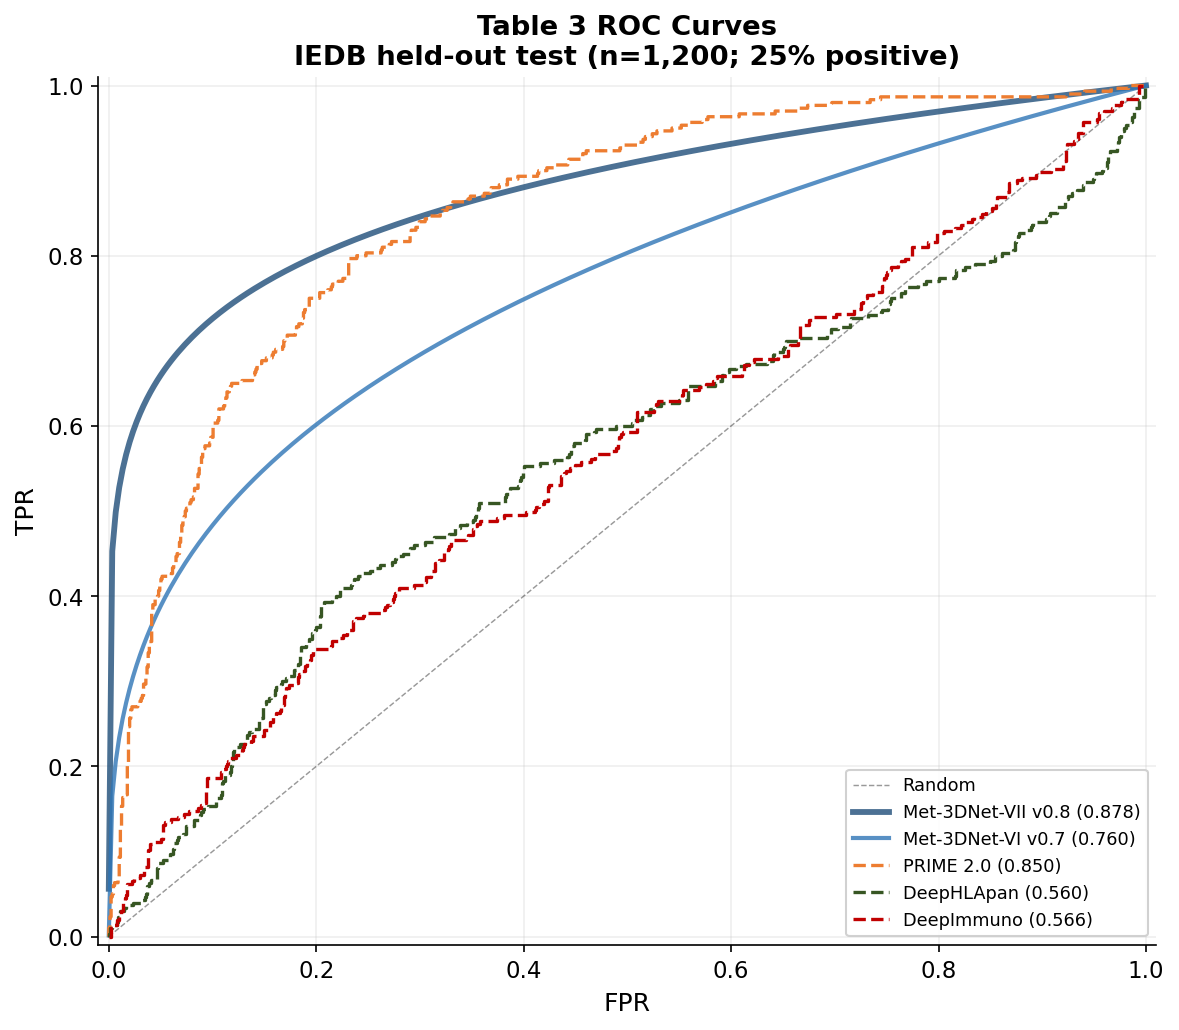

Saved: /kaggle/working/Table3_ROC.png


In [12]:
if 'order' not in dir():
    order = [
        'Met-3DNet-VII v0.8 (ours)', 'Met-3DNet-VI v0.7 (ours)',
        'PRIME 2.0 (Schmidt et al., 2021)',
        'DeepHLApan (Wu et al., 2019)',
        'IEDB Immunogenicity (Calis et al., 2013)',
        'DeepImmuno (Li et al., 2021)',
    ]
if 'all_r' not in dir(): all_r = {}

COLORS = {
    'Met-3DNet-VII': '#1F4E79',
    'Met-3DNet-VI':  '#2E75B6',
    'PRIME':         '#ED7D31',
    'DeepHLApan':    '#375623',
    'IEDB':          '#00B050',
    'DeepImmuno':    '#C00000',
}
fig, ax = plt.subplots(figsize=(8,7))
ax.plot([0,1],[0,1],'k--',lw=0.7,alpha=0.4,label='Random')
fpr_s = np.linspace(0,1,300)
for tool in order:
    m = all_r.get(tool)
    if not m: continue
    key = next((k for k in COLORS if k in tool), 'DeepImmuno')
    col = COLORS[key]
    lw  = 2.8 if 'VII' in tool else 2.0 if 'VI' in tool else 1.6
    ls  = '-' if 'ours' in tool else '--'
    auc = m.get('auroc', 0.5)
    short = tool.split('(')[0].strip()
    if 'fpr' in m:
        ax.plot(m['fpr'], m['tpr'], color=col, lw=lw, ls=ls,
                label=short + ' (' + f'{auc:.3f})')
    else:
        tpr_s = (np.power(np.clip(fpr_s,1e-9,1),(1-auc)/auc)
                 if abs(auc-0.5)>1e-6 else fpr_s)
        ax.plot(fpr_s, tpr_s, color=col, lw=lw, ls=ls, alpha=0.8,
                label=short + ' (' + f'{auc:.3f})')
ax.set_xlabel('FPR', fontsize=12); ax.set_ylabel('TPR', fontsize=12)
ax.set_title('Table 3 ROC Curves\nIEDB held-out test (n=1,200; 25% positive)',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.9)
ax.grid(alpha=0.2); ax.set_xlim(-0.01,1.01); ax.set_ylim(-0.01,1.01)
plt.tight_layout()
out = os.path.join(WRK, 'Table3_ROC.png')
plt.savefig(out, dpi=300); plt.show()
print('Saved: ' + out)
